<a href="https://colab.research.google.com/github/NoeliaOrsini/nova-agente-rag-human-in-the-loop/blob/main/Nova_Agente_RRHH_RAG_HITL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Instalación de la librería**
---
Instalamos la SDK oficial de Google para habilitar la comunicación entre nuestro código y el modelo de IA.

In [1]:
!pip install -q google.genai

### **2. Configuración de credenciales**
---
Cargamos la **API KEY** de forma segura utilizando `userdata`. Esto permite autenticar la conexión sin exponer claves privadas en el código fuente.

In [2]:
from google.colab import userdata
import os
os.environ ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

### **3. Carga de Documentos (Dataset)**
---
Para que el agente pueda analizar la información, primero debemos subir los archivos fuente.
* Este bloque crea una carpeta interna llamada `/PDFs`.
* Habilita un botón para seleccionar documentos desde tu computadora.
* Organiza los archivos automáticamente para que el sistema los encuentre.

In [3]:
# ⚠️ SUBÍ AQUÍ LOS PDF CADA VEZ QUE INICIES SESIÓN
from google.colab import files
os.makedirs ("PDFs", exist_ok= True)
uploader = files.upload ()
for archivo in uploader.keys():
  os.rename (archivo, f"PDFs/{archivo}")

Saving informe 2 technova.pdf to informe 2 technova.pdf


### **4. Herramientas de Procesamiento de PDF**
---
Instalamos las librerías necesarias para que el sistema pueda "leer" el contenido de los archivos PDF y convertirlos en texto procesable por la inteligencia artificial.

In [4]:
!pip install -q langchain-community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


### **5. Cargador de Documentos**
---
Importamos el módulo `PyPDFLoader` de la librería `LangChain`. Este componente es el encargado de actuar como puente, permitiendo que el sistema lea, interprete y cargue el contenido de los archivos PDF para su posterior análisis.

In [5]:
from langchain_community.document_loaders import PyPDFLoader

### **6. Lectura y Consolidación de Documentos**
---
En este paso, recorremos la carpeta `/PDFs` para identificar todos los archivos disponibles. Usamos `PyPDFLoader` para extraer el contenido de cada página y guardarlo en una lista unificada llamada `documentos`, que servirá como la base de conocimientos de nuestra IA.

In [6]:
documentos = []
for archivo2 in os.listdir ("PDFs"):
  if archivo2.endswith('.pdf'): # Filter for actual PDF files
    ruta = os.path.join ("PDFs", archivo2)
    loader = PyPDFLoader (ruta)
    paginas = loader.load()
    documentos.extend (paginas)

### **7. Herramienta de Segmentación**
---
Instalamos el módulo `langchain-text-splitters`, que contiene las funciones necesarias para dividir documentos extensos en fragmentos más pequeños y manejables.

In [7]:
!pip install -q langchain-text-splitters

### **8. Fragmentación Estratégica (Chunking)**
---
Utilizamos `RecursiveCharacterTextSplitter` para dividir el texto en bloques de 400 caracteres.
* **Overlap (40):** Mantiene un pequeño solapamiento entre fragmentos para no perder el contexto entre párrafos.
* **Separators:** Prioriza cortes en saltos de línea o puntos, evitando que las oraciones queden cortadas a la mitad.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
divisor = RecursiveCharacterTextSplitter (
    chunk_size= 400,
    chunk_overlap= 40,
    separators= ["\n\n", "\n", ". ", " ", ""]
)
fragmentos = divisor.split_documents (documentos)

### **9. Motores de Búsqueda y Embeddings**
---
Instalamos las librerías necesarias para transformar el texto en datos vectoriales:
* **langchain-google-genai:** Para usar los modelos de embeddings de Google.
* **faiss-cpu:** El motor de búsqueda de alta velocidad para encontrar fragmentos relevantes.
* **langchain-community:** Para integrar estas herramientas dentro del flujo de trabajo.

In [9]:
!pip install -q langchain-google-genai faiss-cpu langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 22.8 MB/s eta 0:00:00


### **10. Configuración del Modelo de Embeddings**
---
Importamos y configuramos el modelo `gemini-embedding-001`. Este componente es esencial para transformar nuestros fragmentos de texto en representaciones numéricas (vectores), permitiendo que el sistema realice búsquedas semánticas precisas en lugar de solo buscar palabras clave.

In [10]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

### **11. Construcción del Almacén Vectorial (FAISS)**
---
En este paso, cruzamos los `fragmentos` de texto con los `embeddings` para crear nuestra base de datos vectorial.

**Nota para proyectos a gran escala:** Si trabajas con un volumen muy alto de PDFs, podrías crear almacenes por separado (ej. `vectorstore1`, `vectorstore2`) y luego utilizar la función `merge_from()` para unificarlos en un solo índice. En este caso, al ser un volumen controlado, consolidamos todo en un único `vectorstore`.

In [11]:
vectorstore = FAISS.from_documents(
    documents=fragmentos,
    embedding=embeddings
)

### **12. Configuración del Modelo de Lenguaje y Recuperador**
---
Definimos el modelo que generará las respuestas y el mecanismo de búsqueda:
* **Gemini 2.5 Flash:** Utilizamos este modelo con una temperatura de `0.2` para asegurar respuestas precisas, técnicas y con baja "creatividad" (evitando alucinaciones).
* **Retriever:** Configuramos el buscador para que, ante cada consulta, recupere los **4 fragmentos (`k=4`)** más relevantes de nuestra base de datos FAISS.

In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

### **13. Función de Recuperación y Trazabilidad de Fuentes**
---
Definimos la lógica para extraer información relevante de la base de conocimientos. A diferencia de un sistema RAG básico, esta función:
* **Identifica el origen:** Extrae el nombre del archivo (`source`) de los metadatos de cada fragmento.
* **Estructura el Contexto:** Organiza la información en bloques claros que especifican qué documento contiene qué contenido.
* **Seguridad:** Incluye una validación para informar si la consulta no arrojó resultados en la base de datos de TechNova.

In [13]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y lo prepara para el informe."""
    # Paso 1: Buscar los fragmentos (chunks) más relevantes
    docs = retriever.invoke(pregunta)

    # Nuevo join que incluye el nombre del archivo (metadatos)
    contexto_lista = []
    for doc in docs:
        # Extraemos el nombre del archivo de los metadatos
        nombre_archivo = doc.metadata.get('source', 'Archivo desconocido')
        # Limpiamos la ruta para que solo quede el nombre (ej: informe.pdf)
        nombre_archivo = nombre_archivo.split('/')[-1].split('\\')[-1]

        # Unimos nombre y contenido en un bloque
        bloque = f"DOCUMENTO: {nombre_archivo}\nCONTENIDO: {doc.page_content}"
        contexto_lista.append(bloque)

    # Unimos todos los bloques con separadores claros
    contexto = "\n\n---\n\n".join(contexto_lista)

    # Paso 2: Verificación de seguridad
    if not contexto.strip():
        return "No se encontró información específica en los documentos de TechNova."

    # Paso 3: Devolvemos el contexto enriquecido al Grafo
    return contexto

### **14. Herramientas de Agente y Generación de Reportes**
---
Instalamos el ecosistema final para que el asistente sea completamente funcional:
* **langgraph:** Para gestionar el flujo de trabajo y la toma de decisiones del agente.
* **google-search-results:** Permite que Nova realice búsquedas en la web si la información no está en los PDF.
* **markdown & fpdf2:** Herramientas para procesar texto enriquecido y exportar los resultados finales a formato PDF profesional.

In [14]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.3 MB/s eta 0:00:00


### **15. Configuración de Búsqueda Externa (Web Search)**
---
Para que el asistente no dependa exclusivamente de la documentación cargada, integramos **SerpApi**. Esta clave permite que Nova realice consultas en la web en tiempo real, complementando su base de conocimientos con información actualizada de internet.

In [15]:
os.environ ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

### **16. Inicialización del Motor de Búsqueda (SerpApi)**
---
Configuramos el buscador externo utilizando `SerpAPIWrapper`. Esta herramienta actúa como el "navegador" del asistente, permitiéndole realizar consultas en Google y procesar los resultados para complementar la base de conocimientos cuando sea necesario.

In [16]:
from langchain_community.utilities import SerpAPIWrapper
buscador = SerpAPIWrapper ()


### **17. Arquitectura del Flujo de Trabajo (LangGraph)**
---
Antes de programar la lógica, definimos el mapa de decisiones de nuestra IA. El agente actúa como un director de orquesta que evalúa la consulta y decide el camino más eficiente:

* **RAG:** Si la información es interna y específica de la documentación.
* **WEB:** Si la consulta requiere datos actualizados o externos.

**Esquema del Grafo:**

```
┌────────┐   ┌────────┐   ┌──────────────┐
│ START  │ → │ AGENTE │ → │  RAG | WEB   │
└────────┘   └────────┘   └──────┬───────┘
                                 │
                 ┌───────────────┴───────────────┐
                 ↓                               ↓
        ┌──────────────────┐            ┌──────────────────┐
        │ DOCUMENTOS (RAG) │            │  WEB (SERPAPI)   │
        └────────┬─────────┘            └────────┬─────────┘
                 └──────────────┬───────────────┘
                                ↓
                      ┌──────────────────┐
                      │  GENERACIÓN      │
                      │  (MARKDOWN)      │
                      └────────┬─────────┘
                               ↓
                ────── Flujo posterior al grafo ──────
                               ↓
                      ┌──────────────────┐
                      │ PREVISUALIZACIÓN │
                      └────────┬─────────┘
                               ↓
                      ┌──────────────────┐
                      │ APROBACIÓN (HITL)│
                      └────────┬─────────┘
                               ↓
                      ┌──────────────────┐
                      │      PDF         │
                      └────────┬─────────┘
                               ↓
                          ┌────────┐
                          │  END   │
                          └────────┘
```

# 🧠 PUNTO 1: EL CEREBRO (Lógica y Agente)

Este bloque es el motor cognitivo de Nova. Su responsabilidad es recibir la consulta, razonar sobre cuál fuente utilizará y redactar un borrador en texto limpio, listo para ser entregado al Punto 2 (El Diseñador), quien se encargará de darle el formato institucional final.



### **18. Definición del Estado del Agente (AgentState)**
---
Para que la información fluya correctamente entre los nodos del grafo, definimos una estructura de datos clara mediante `TypedDict`. El `AgentState` actúa como la memoria de corto plazo de nuestro proceso, almacenando:
* **pregunta:** La consulta original del usuario.
* **fuente:** El camino elegido (RAG o Web).
* **contexto:** La información recuperada de los documentos o de internet.
* **respuesta:** El informe final generado en formato Markdown.

### **18.1 Implementación de la Lógica del Grafo (Nodos y Aristas)**
---
En esta sección programamos el comportamiento de cada estación del proceso:
1.  **Nodo Agente:** Clasifica la pregunta (RAG o Web) usando lógica de negocio de TechNova.
2.  **Nodo RAG:** Recupera datos de los PDFs con trazabilidad de archivos.
3.  **Nodo Web:** Utiliza SerpApi para obtener fragmentos de internet y sus enlaces.
4.  **Nodo Markdown:** Actúa como Nova 🤖, redactando el informe final bajo reglas estrictas de precisión, trazabilidad (sin asteriscos para evitar errores en el PDF) y con la fecha actualizada a 2026.

Finalmente, **compilamos el grafo** y generamos un diagrama visual para verificar que todas las conexiones sean correctas.

### **18.2. Ajuste de Inteligencia y Profundidad Analítica**
---
Hemos optimizado el nodo de generación de respuestas para que Nova recupere su capacidad de análisis técnico. Los ajustes principales incluyen:
* **Análisis Normativo:** Ahora tiene la instrucción explícita de citar artículos, leyes o jurisprudencia presentes en el contexto.
* **Extensión Detallada:** Se elimina la tendencia a la brevedad; Nova debe explicar el "qué" y el "cómo" de los cambios (ej. reformas laborales).
* **Trazabilidad Jurídica:** Mantiene la limpieza visual (sin símbolos Markdown que rompan el PDF) pero con un rigor técnico de nivel legal.

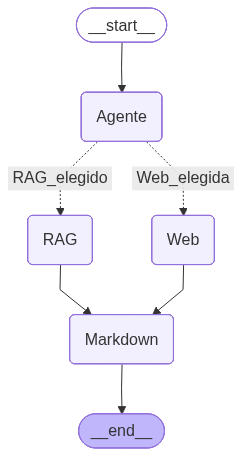

In [17]:
import datetime
import re
import textwrap
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# --- 1. CONFIGURACIÓN DEL ESTADO ---
# Usamos el estado para que la información fluya entre nodos
class AgentState(TypedDict):
    pregunta: str
    fuente: str
    contexto: str
    respuesta: str

# Zona horaria de Argentina
TZ_AR = datetime.timezone(datetime.timedelta(hours=-3))

# --- 2. DEFINICIÓN DE LOS NODOS  ---

def nodo_agente(state: AgentState):
    pregunta = state["pregunta"]
    prompt = f"""Eres el clasificador de consultas de Recursos Humanos de TechNova Solutions.
    Tu tarea es decidir si la pregunta requiere datos de la información cargada en PDFs (RAG) o información GENERAL externa (WEB).

    REGLAS DE CLASIFICACIÓN:
    - Responde SOLO 'RAG' si la pregunta es sobre: empleados específicos (ID), listas de personas, sueldos, días de vacaciones, legajos, fechas de ingreso o métricas de desempeño.
    - Responde SOLO 'Web' si la pregunta es sobre: leyes laborales, feriados nacionales, tendencias de mercado, convenios colectivos generales o temas de interés general.

    Pregunta: {pregunta}
    Respuesta (RAG o Web):"""

    respuesta = llm.invoke(prompt)
    fuente_detectada = respuesta.content.strip().upper()
    fuente = "RAG" if "RAG" in fuente_detectada else "Web"

    print(f"📍 Nova determinó que la consulta es de tipo: {fuente}")
    return {"fuente": fuente}

def nodo_rag(state: AgentState):
    # Llama a la función de búsqueda en PDFs
    contexto = preguntar_rag(state["pregunta"])
    return {"contexto": contexto}

def nodo_web(state: AgentState):
    pregunta = state["pregunta"]
    respuesta_serp = buscador.results(pregunta)
    resultados = respuesta_serp.get("organic_results", [])

    if resultados:
        contexto = "\n\n".join([r.get("snippet", "") for r in resultados[:3]])
        link_real = resultados[0].get("link", "Enlace no encontrado")
    else:
        contexto = "No se hallaron resultados detallados."
        link_real = "Web"

    return {"contexto": contexto, "fuente": link_real}

def nodo_markdown(state: AgentState):
    fuente_real = state.get("fuente", "Enlace no disponible")

    prompt = f"""Eres Nova 🤖, la asistente experta en Asuntos Legales y Recursos Humanos de TechNova Solutions S.A.
    Tu objetivo es redactar informes de ALTA PROFUNDIDAD, técnicos y exhaustivos.

    REGLAS DE FORMATO (ESTRICTAS):
    - NO uses símbolos de Markdown como # o asteriscos (**).
    - Usa títulos en MAYÚSCULAS y deja renglones de espacio entre secciones.
    - Si necesitas listar puntos, usa guiones simples (-) o números.

    ESTRUCTURA DEL INFORME:
    1. TÍTULO: Encabezado técnico descriptivo.
    2. ANÁLISIS DETALLADO:
       - No resumas de forma genérica. CITA artículos, incisos o párrafos relevantes cuando se te pide analizar legislación.
       - Explica cómo afectan estos cambios a la operativa de la empresa.
    3. HALLAZGOS ESPECÍFICOS: Datos cuantitativos, nombres, ids, fechas sin omitir detalles.
    4. CONCLUSIÓN: Resumen de la situación jurídica actual.
    5. ORIGEN Y TRAZABILIDAD:
       - Si es RAG: "Fuente: Documentación interna. Archivo: [Nombre exacto]".
       - Si es Web: "Fuente: Consulta externa. Enlace: {fuente_real}".

    REGLAS CRÍTICAS:
    - PROHIBIDO incluir recomendaciones, sugerencias o acciones si no fueron solicitadas explícitamente.
    - NO OMITAS INFORMACIÓN.
    - CONSISTENCIA NUMÉRICA: Las cantidades deben coincidir con las listas.
    - PROFUNDIDAD CONTROLADA: Desarrolla leyes y normativa a fondo si se te pide que las analices.
    - CONTEXTO TEMPORAL: Prioriza información actualizada a 2026.
    - NO INVENTES NI INTERPRETES fuera del contexto.
    - Si el contexto no identifica claramente número de ley o estado (proyecto/sancionada), indícalo como no confirmado.
    - TONO TÉCNICO Y OBJETIVO.

    Contexto (fuente: {state["fuente"]}):
    {state["contexto"]}

    Pregunta: {state["pregunta"]}

    Respuesta (Genera un informe detallado, completo, profesional y sin símbolos de Markdown):"""

    respuesta = llm.invoke(prompt)
    return {"respuesta": respuesta.content}

# --- 3. LÓGICA DE CONEXIÓN DEL GRAFO ---

def decidir_fuente(state: AgentState):
    return "RAG_elegido" if state["fuente"] == "RAG" else "Web_elegida"

grafo = StateGraph(AgentState)
grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente, {
    "RAG_elegido": "RAG",
    "Web_elegida": "Web"
})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

# Compilación final del cerebro
agente = grafo.compile()

# Visualización para confirmar el flujo
try:
    display(Image(agente.get_graph().draw_mermaid_png()))
except:
    print("✅ Grafo compilado correctamente.")

# 🎨 PUNTO 2: EL DISEÑADOR (Identidad Visual y Exportación)
---

En este módulo, transformamos la respuesta textual de Nova en un documento oficial de TechNova Solutions. Aplicamos la identidad corporativa, limpiamos el formato y preparamos el archivo PDF para su entrega final.

### **19. Configuración de Identidad Visual**
---
Para que los informes generados tengan un acabado profesional y corporativo, procedemos a cargar el logotipo de la empresa. Este archivo (`logo_technova.png`) será integrado automáticamente en el encabezado de cada PDF que genere Nova.

In [18]:
from google.colab import files

# Esto se corre una sola vez al abrir el cuaderno
print("Seleccioná el archivo logo_technova.png de tu carpeta Mis Documentos:")
uploaded = files.upload() # ⚠️ SUBÍ AQUÍ EL LOGO

Seleccioná el archivo logo_technova.png de tu carpeta Mis Documentos:


Saving logo_technova.png to logo_technova.png


### **20. Ejecución y Generación de Entregables (PDF)**
---
Este bloque actúa como el puente final entre el razonamiento de la IA y el usuario. Aquí separamos el procesamiento de la información del diseño visual para garantizar entregables de calidad corporativa.

1.  **Función Cerebro (`ejecutar_agente`):** Activa el grafo de LangGraph. Incluye un sistema de **control de errores inteligente** que identifica si la API se agotó (Error 429) o si el servidor está saturado (Error 503), permitiendo una respuesta controlada al usuario.
2.  **Función Diseñador (`generar_reporte_pdf`):** Transforma el texto plano en un documento corporativo profesional.
    * Limpia cualquier rastro de caracteres especiales.
    * Inserta el logotipo y aplica la paleta de colores de **TechNova Solutions** (Azul corporativo).
    * Genera un nombre de archivo dinámico con la fecha y hora exacta de Argentina y prepara el archivo para la descarga.

In [19]:
# BLOQUE A
# --- 1. LLAMA AL CEREBRO  ---
import datetime

def ejecutar_agente(pregunta):
    try:
        resultado = agente.invoke({
            "pregunta": pregunta,
            "fuente": "",
            "contexto": "",
            "respuesta": ""
        })
        # Limpieza para el PDF
        texto_final = resultado["respuesta"].encode('latin-1', 'ignore').decode('latin-1')
        return texto_final, resultado["fuente"]

    except Exception as e:
        error_msg = str(e).lower()
        if "429" in error_msg or "quota" in error_msg:
            return None, "CUOTA_AGOTADA"
        elif "503" in error_msg or "overloaded" in error_msg:
            return None, "SERVIDOR_SATURADO"
        else:
            return None, f"ERROR_TECNICO: {e}"

# --- 2. FUNCIÓN DISEÑADOR ---

def generar_reporte_pdf(texto_ia, pregunta_original):

    if texto_ia is None: return
    from fpdf import FPDF
    pdf = FPDF()
    pdf.add_page()
    texto_ia = texto_ia.replace("**", "").replace("*", "").replace("#", "")
    texto_limpio = texto_ia.encode('latin-1', 'ignore').decode('latin-1')

    lineas = [l.strip() for l in texto_limpio.split('\n') if l.strip()]
    titulo = lineas[0] if lineas else "INFORME CORPORATIVO"
    contenido = "\n".join(lineas[1:])

    try:
        pdf.image('logo_technova.png', x=10, y=8, w=45)
    except:
        pass

    pdf.set_text_color(0, 64, 128)
    pdf.set_font("Helvetica", 'B', 18)
    pdf.cell(0, 20, "TECHNOVA SOLUTIONS S.A.", align="R", new_x="LMARGIN", new_y="NEXT")

    pdf.set_draw_color(0, 64, 128)
    pdf.set_line_width(0.6)
    pdf.line(10, 35, 200, 35)
    pdf.ln(15)

    pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", 'B', 14)
    pdf.multi_cell(0, 10, titulo.upper(), align="C")
    pdf.ln(5)

    pdf.set_font("Helvetica", size=11)
    pdf.multi_cell(0, 8, contenido, align="J")

    tz_ar = datetime.timezone(datetime.timedelta(hours=-3))
    ahora = datetime.datetime.now(tz_ar)
    nombre_archivo = f"Informe_Nova_{ahora.strftime('%d-%m-%Y_%H-%M')}.pdf"

    pdf.output(nombre_archivo)
    return nombre_archivo

# 🚀 PUNTO 3: LA EJECUCIÓN (Interfaz Operativa de Nova)
---


### **21. Interfaz Operativa de Nova**
---
# Este es el punto de interacción final. La interfaz permite una experiencia de usuario fluida y profesional:
* **Barra de Consulta:** Espacio interactivo para realizar preguntas a la IA.
* **Procesamiento en Tiempo Real:** Nova informa visualmente cada etapa (Búsqueda de fuente, Clasificación y Redacción).
* **Manejo de Errores Resiliente:** Si la API excede su cuota, el sistema informa con claridad en lugar de romperse.
* **Control humano:** Antes de generar el PDF, el usuario puede revisar el borrador y decidir si aprueba o rechaza el informe, asegurando que solo los documentos validados se descarguen.

In [23]:
# BLOQUE B (Interfaz) ------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output
import sys

print("-" * 80)
print("✨🌀 Soy Nova, tu asistente de TechNova. ¿En qué te puedo ayudar?")
print("-" * 80)

input_box = widgets.Text(
    value='',
    placeholder='Escribe tu consulta aquí y presiona ENTER...',
    description='Consulta:',
    layout=widgets.Layout(width='95%')
)

output_area = widgets.Output()
display(input_box, output_area)

def al_presionar_enter(sender):
    consulta = input_box.value.strip()
    if not consulta:
        with output_area:
            print("⚠️ Por favor, ingresá una consulta.")
        return

    with output_area:
        clear_output()
        print(f"⏳ Nova está analizando tu consulta...")
        print(f"🔍 Seleccionando la fuente de información (RAG/Web)...")
        print(f"✍️ Confeccionando el informe final... (esto puede demorar unos minutos)")
        sys.stdout.flush()

        try:
            respuesta, resultado_agente = ejecutar_agente(consulta)

            if respuesta is None:
                if resultado_agente == "CUOTA_AGOTADA":
                    print("\n⚠️ Límite de cuota alcanzado. Por favor, intenta nuevamente mañana.")
                elif resultado_agente == "SERVIDOR_SATURADO":
                    print("\n🌐 El servidor está saturado. Por favor, intenta de nuevo en unos minutos.")
                else:
                    print(f"\n❌ Inconveniente técnico: {resultado_agente}")
                return

            fuente = resultado_agente
            mensaje_fuente = f"📍 Origen: {fuente}"
            if "http" in fuente.lower():
                mensaje_fuente = f"🌐 Información obtenida de la web: {fuente}"
            else:
                mensaje_fuente = "📂 Información recuperada de documentos internos de la empresa"
            print(mensaje_fuente)
            print(f"📄 Informe generado con éxito.")
            print("-" * 30)

            print("\n" + "═"*60)
            print("📋 REVISIÓN PREVIA DEL INFORME")
            print("═"*60)
            print(respuesta)
            print("═"*60)

            btn_si = widgets.Button(description="✅ APROBAR Y DESCARGAR", button_style='success', layout=widgets.Layout(width='45%'))
            btn_no = widgets.Button(description="❌ RECHAZAR", button_style='danger', layout=widgets.Layout(width='45%'))
            fila_botones = widgets.HBox([btn_si, btn_no])

            btn_si.on_click(lambda b: al_clic_boton(b, respuesta, consulta, fuente, fila_botones))
            btn_no.on_click(lambda b: al_clic_boton(b, respuesta, consulta, fuente, fila_botones))
            display(fila_botones)

        except Exception as e:
            print(f"❌ Error inesperado: {e}")

def al_clic_boton(b, respuesta, consulta, fuente, contenedor):

    with output_area:
        if b.description == "✅ APROBAR Y DESCARGAR":
            b.disabled = True
            contenedor.close()

            archivo = generar_reporte_pdf(respuesta, consulta)
            from google.colab import files
            files.download(archivo)

            print(f"\n✅ Aprobado. Se descargó con éxito: {archivo}")
            input_box.value = ""

        elif b.description == "❌ RECHAZAR":
            print("\n🚫 Informe rechazado. Se cancela la descarga del documento.")

        contenedor.close()

input_box.on_submit(al_presionar_enter)

--------------------------------------------------------------------------------
✨🌀 Soy Nova, tu asistente de TechNova. ¿En qué te puedo ayudar?
--------------------------------------------------------------------------------


Text(value='', description='Consulta:', layout=Layout(width='95%'), placeholder='Escribe tu consulta aquí y pr…

Output()